# Parallel Image Segmentation using Fuzzy C-Means (FCM)

### Algorithm Overview: Fuzzy C-Means (FCM)
Unlike standard K-Means where each pixel belongs to exactly one cluster (hard clustering), FCM assigns a *degree of membership* to each pixel for every cluster. This allows for softer boundaries, which is especially useful in medical imaging where tissue boundaries are often blurry or overlapping.

The algorithm minimizes an objective function and operates through the following iterative steps:

**Step 1: Initialization**
* Define the number of clusters ($C$).
* Define the fuzziness parameter ($m > 1$). A common choice is $m = 2.0$.
* Define the convergence threshold ($\epsilon$).
* Initialize a membership matrix $U$ of size $N \times C$ (where $N$ is the number of pixels) with random values between 0 and 1, ensuring the sum of memberships for each pixel equals 1.

**Step 2: Calculate Cluster Centers (Centroids)**
In each iteration, the algorithm calculates the new center $C_j$ for each cluster. The center is the weighted average of all pixel intensities ($x_i$), where the weights are the memberships raised to the power of $m$:
$$C_j = \frac{\sum_{i=1}^{N} u_{ij}^m \cdot x_i}{\sum_{i=1}^{N} u_{ij}^m}$$

**Step 3: Calculate Distances**
Calculate the Euclidean distance ($d_{ij}$) between each pixel $x_i$ and each cluster center $C_j$. Because we are using 1-channel grayscale images, this is simply the absolute difference:
$$d_{ij} = |x_i - C_j|$$

**Step 4: Update the Membership Matrix**
Recalculate the degree of membership $u_{ij}$ for every pixel to every cluster based on its relative distance to all centers:
$$u_{ij} = \frac{1}{\sum_{k=1}^{C} \left( \frac{d_{ij}}{d_{ik}} \right)^{\frac{2}{m-1}}}$$

**Step 5: Check for Convergence**
Compare the new membership matrix to the previous one. Find the maximum absolute difference across all elements.
* If the maximum difference is less than the threshold $\epsilon$, the algorithm has converged and stops.
* Otherwise, it returns to **Step 2** and repeats the process.

**Step 6: Defuzzification (Image Generation)**
Once converged, the soft memberships are translated into a final image.
* **Hard Clustering Mode:** The pixel is assigned the exact intensity of the cluster center to which it has the highest membership score.
* **Soft Clustering Mode:** The pixel's final intensity is a blended weighted average of all cluster centers based on its membership scores.

In [1]:
# Download required stb_image headers for image processing
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

# Create directory for the input image
!mkdir -p images

### 3. CUDA Kernel Configuration Details
To maximize GPU occupancy and memory throughput, the parallel implementation uses the following configuration:
* **Grid and Block Size:** 1D blocks containing 256 threads. The grid size is dynamically calculated based on the total number of pixels ($N$) as `(N + 255) / 256`.
* **Memory Model:** * `cudaMalloc` and `cudaMemcpy` are used to transfer the linearized RGB pixel arrays and membership matrices from Host (CPU) to Device (GPU).
    * `atomicAdd` is utilized in global memory to safely accumulate cluster center coordinates across thousands of concurrent threads.

### 4. Kernels Used
1. `calc_centers_accumulate_kernel`: Computes the weighted sums of pixels for new cluster centers.
2. `calc_centers_divide_kernel`: Finalizes the center positions by dividing the accumulated sums by the total weights.
3. `update_membership_kernel`: Re-evaluates the distance of each pixel to the new centers and updates the membership matrix.

In [14]:
%%writefile FCM_Segmentation_rgb.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>
#include <cuda_runtime.h>
#include <device_launch_parameters.h>

#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

// --- Configuration ---
int C = 4;               // Number of clusters (Now dynamic!)
#define M 2.0f           // Fuzziness parameter (m > 1)
#define EPSILON 0.0001f  // Convergence threshold
#define MAX_ITER 100     // Maximum iterations

// Helper macro for checking CUDA errors
#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error in %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

// --- CPU Implementation ---
float calculate_distance(float r1, float g1, float b1, float r2, float g2, float b2) {
    float dr = r1 - r2;
    float dg = g1 - g2;
    float db = b1 - b2;
    return sqrtf(dr * dr + dg * dg + db * db) + 1e-6f;
}

void fcm_cpu(float* pts_r, float* pts_g, float* pts_b, float* u, float* centers_r, float* centers_g, float* centers_b, int N) {
    float* u_new = (float*)malloc(N * C * sizeof(float));
    int iter = 0;
    float max_diff;

    do {
        max_diff = 0.0f;
        for (int j = 0; j < C; j++) {
            float num_r = 0.0f, num_g = 0.0f, num_b = 0.0f, den = 0.0f;
            for (int i = 0; i < N; i++) {
                float u_ij_m = powf(u[i * C + j], M);
                num_r += u_ij_m * pts_r[i];
                num_g += u_ij_m * pts_g[i];
                num_b += u_ij_m * pts_b[i];
                den += u_ij_m;
            }
            centers_r[j] = num_r / den;
            centers_g[j] = num_g / den;
            centers_b[j] = num_b / den;
        }

        float exp =  2.0f / (M - 1.0f);
        for (int i = 0; i < N; i++) {
            for (int j = 0; j < C; j++) {
                float dist_ij = calculate_distance(pts_r[i], pts_g[i], pts_b[i], centers_r[j], centers_g[j], centers_b[j]);
                float sum = 0.0f;
                for (int k = 0; k < C; k++) {
                    float dist_ik = calculate_distance(pts_r[i], pts_g[i], pts_b[i], centers_r[k], centers_g[k], centers_b[k]);
                    sum += powf(dist_ij / dist_ik, exp );
                }
                u_new[i * C + j] = 1.0f / sum;

                float diff = fabsf(u_new[i * C + j] - u[i * C + j]);
                if (diff > max_diff) max_diff = diff;
            }
        }

        for (int i = 0; i < N * C; i++) {
            u[i] = u_new[i];
        }
        iter++;
    } while (max_diff > EPSILON && iter < MAX_ITER);

    printf("CPU finished in %d iterations.\n", iter);
    free(u_new);
}

// --- GPU Implementation ---
__global__ void calc_centers_accumulate_kernel(float* pts_r, float* pts_g, float* pts_b, float* u,
    float* num_r, float* num_g, float* num_b, float* den, int n, int c, float m) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        for (int j = 0; j < c; j++) {
            float u_ij_m = powf(u[i * c + j], m);
            atomicAdd(&num_r[j], u_ij_m * pts_r[i]);
            atomicAdd(&num_g[j], u_ij_m * pts_g[i]);
            atomicAdd(&num_b[j], u_ij_m * pts_b[i]);
            atomicAdd(&den[j], u_ij_m);
        }
    }
}

__global__ void calc_centers_divide_kernel(float* centers_r, float* centers_g, float* centers_b,
    float* num_r, float* num_g, float* num_b, float* den, int c) {
    int j = blockIdx.x * blockDim.x + threadIdx.x;
    if (j < c) {
        centers_r[j] = num_r[j] / den[j];
        centers_g[j] = num_g[j] / den[j];
        centers_b[j] = num_b[j] / den[j];
    }
}

__global__ void update_membership_kernel(float* pts_r, float* pts_g, float* pts_b,
    float* centers_r, float* centers_g, float* centers_b, float* u_new, int n, int c, float m) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    float exp =  2.0f / (m - 1.0f);
    if (i < n) {
        for (int j = 0; j < c; j++) {
            float dr_ij = pts_r[i] - centers_r[j];
            float dg_ij = pts_g[i] - centers_g[j];
            float db_ij = pts_b[i] - centers_b[j];
            float dist_ij = sqrtf(dr_ij * dr_ij + dg_ij * dg_ij + db_ij * db_ij) + 1e-6f;

            float sum = 0.0f;
            for (int k = 0; k < c; k++) {
                float dr_ik = pts_r[i] - centers_r[k];
                float dg_ik = pts_g[i] - centers_g[k];
                float db_ik = pts_b[i] - centers_b[k];
                float dist_ik = sqrtf(dr_ik * dr_ik + dg_ik * dg_ik + db_ik * db_ik) + 1e-6f;
                sum += powf(dist_ij / dist_ik, exp);
            }
            u_new[i * c + j] = 1.0f / sum;
        }
    }
}

void fcm_gpu(float* h_pts_r, float* h_pts_g, float* h_pts_b, float* h_u,
             float* h_centers_r, float* h_centers_g, float* h_centers_b, int N) {
    float* d_pts_r, * d_pts_g, * d_pts_b, * d_u, * d_u_new;
    float* d_centers_r, * d_centers_g, * d_centers_b;
    float* d_num_r, * d_num_g, * d_num_b, * d_den;

    size_t pts_size = N * sizeof(float);
    size_t u_size = N * C * sizeof(float);
    size_t c_size = C * sizeof(float);

    CUDA_CHECK(cudaMalloc(&d_pts_r, pts_size));
    CUDA_CHECK(cudaMalloc(&d_pts_g, pts_size));
    CUDA_CHECK(cudaMalloc(&d_pts_b, pts_size));
    CUDA_CHECK(cudaMalloc(&d_u, u_size));
    CUDA_CHECK(cudaMalloc(&d_u_new, u_size));
    CUDA_CHECK(cudaMalloc(&d_centers_r, c_size));
    CUDA_CHECK(cudaMalloc(&d_centers_g, c_size));
    CUDA_CHECK(cudaMalloc(&d_centers_b, c_size));
    CUDA_CHECK(cudaMalloc(&d_num_r, c_size));
    CUDA_CHECK(cudaMalloc(&d_num_g, c_size));
    CUDA_CHECK(cudaMalloc(&d_num_b, c_size));
    CUDA_CHECK(cudaMalloc(&d_den, c_size));

    CUDA_CHECK(cudaMemcpy(d_pts_r, h_pts_r, pts_size, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_pts_g, h_pts_g, pts_size, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_pts_b, h_pts_b, pts_size, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_u, h_u, u_size, cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks_N = (N + threads - 1) / threads;
    int blocks_C = (C + threads - 1) / threads;

    int iter = 0;
    float max_diff;
    float* h_u_new = (float*)malloc(u_size);

    do {
        CUDA_CHECK(cudaMemset(d_num_r, 0, c_size));
        CUDA_CHECK(cudaMemset(d_num_g, 0, c_size));
        CUDA_CHECK(cudaMemset(d_num_b, 0, c_size));
        CUDA_CHECK(cudaMemset(d_den, 0, c_size));

        calc_centers_accumulate_kernel<<<blocks_N, threads>>>(d_pts_r, d_pts_g, d_pts_b, d_u, d_num_r, d_num_g, d_num_b, d_den, N, C, M);
        cudaDeviceSynchronize();

        calc_centers_divide_kernel<<<blocks_C, threads>>>(d_centers_r, d_centers_g, d_centers_b, d_num_r, d_num_g, d_num_b, d_den, C);
        cudaDeviceSynchronize();

        update_membership_kernel<<<blocks_N, threads>>>(d_pts_r, d_pts_g, d_pts_b, d_centers_r, d_centers_g, d_centers_b, d_u_new, N, C, M);
        cudaDeviceSynchronize();

        CUDA_CHECK(cudaMemcpy(h_u_new, d_u_new, u_size, cudaMemcpyDeviceToHost));
        max_diff = 0.0f;
        for (int i = 0; i < N * C; i++) {
            float diff = fabsf(h_u_new[i] - h_u[i]);
            if (diff > max_diff) max_diff = diff;
            h_u[i] = h_u_new[i];
        }

        float* temp = d_u;
        d_u = d_u_new;
        d_u_new = temp;

        iter++;
    } while (max_diff > EPSILON && iter < MAX_ITER);

    CUDA_CHECK(cudaMemcpy(h_centers_r, d_centers_r, c_size, cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_centers_g, d_centers_g, c_size, cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_centers_b, d_centers_b, c_size, cudaMemcpyDeviceToHost));

    printf("GPU finished in %d iterations.\n", iter);

    free(h_u_new);
    cudaFree(d_pts_r); cudaFree(d_pts_g); cudaFree(d_pts_b);
    cudaFree(d_u); cudaFree(d_u_new);
    cudaFree(d_centers_r); cudaFree(d_centers_g); cudaFree(d_centers_b);
    cudaFree(d_num_r); cudaFree(d_num_g); cudaFree(d_num_b); cudaFree(d_den);
}

// --- Main Program ---
int main(int argc, char** argv) {
    // Default values
    const char* img_path = "images/Sample_6_Slice_97.png";
    bool hard_clustering = true;

    // Parse Command Line Arguments!
    if (argc > 1) img_path = argv[1];
    if (argc > 2) C = atoi(argv[2]); // Override global C
    if (argc > 3) hard_clustering = (atoi(argv[3]) != 0);

    int width, height, channels;
    unsigned char* img_data = stbi_load(img_path, &width, &height, &channels, 3);
    if (!img_data) {
        fprintf(stderr, "Failed to load image: %s\n", img_path);
        return 1;
    }

    printf("Loaded image: %s (%dx%d)\n", img_path, width, height);
    printf("Settings: Clusters=%d, Mode=%s\n", C, hard_clustering ? "Hard" : "Soft");

    int N = width * height;
    srand(42);

    size_t pts_size = N * sizeof(float);
    size_t u_size = N * C * sizeof(float);
    size_t c_size = C * sizeof(float);

    float* h_pts_r = (float*)malloc(pts_size);
    float* h_pts_g = (float*)malloc(pts_size);
    float* h_pts_b = (float*)malloc(pts_size);
    float* h_u_initial = (float*)malloc(u_size);
    float* h_u_cpu = (float*)malloc(u_size);
    float* h_centers_r_cpu = (float*)malloc(c_size);
    float* h_centers_g_cpu = (float*)malloc(c_size);
    float* h_centers_b_cpu = (float*)malloc(c_size);
    float* h_u_gpu = (float*)malloc(u_size);
    float* h_centers_r_gpu = (float*)malloc(c_size);
    float* h_centers_g_gpu = (float*)malloc(c_size);
    float* h_centers_b_gpu = (float*)malloc(c_size);

    for (int i = 0; i < N; i++) {
        h_pts_r[i] = (float)img_data[i * 3 + 0];
        h_pts_g[i] = (float)img_data[i * 3 + 1];
        h_pts_b[i] = (float)img_data[i * 3 + 2];

        float sum = 0.0f;
        for (int j = 0; j < C; j++) {
            float val = (float)rand() / RAND_MAX;
            h_u_initial[i * C + j] = val;
            sum += val;
        }
        for (int j = 0; j < C; j++) {
            h_u_initial[i * C + j] /= sum;
            h_u_cpu[i * C + j] = h_u_initial[i * C + j];
            h_u_gpu[i * C + j] = h_u_initial[i * C + j];
        }
    }

    printf("\nStarting CPU Fuzzy C-Means...\n");
    clock_t start_cpu = clock();
    fcm_cpu(h_pts_r, h_pts_g, h_pts_b, h_u_cpu, h_centers_r_cpu, h_centers_g_cpu, h_centers_b_cpu, N);
    clock_t end_cpu = clock();
    double cpu_time = ((double)(end_cpu - start_cpu)) / CLOCKS_PER_SEC;
    printf("CPU Time: %f seconds\n", cpu_time);

    printf("\nStarting GPU Fuzzy C-Means...\n");
    clock_t start_gpu = clock();
    fcm_gpu(h_pts_r, h_pts_g, h_pts_b, h_u_gpu, h_centers_r_gpu, h_centers_g_gpu, h_centers_b_gpu, N);
    clock_t end_gpu = clock();
    double gpu_time = ((double)(end_gpu - start_gpu)) / CLOCKS_PER_SEC;
    printf("GPU Time: %f seconds\n", gpu_time);

    unsigned char* out_img_data = (unsigned char*)malloc(N * 3);
    if(hard_clustering){
        for (int i = 0; i < N; i++) {
            int best_cluster = 0;
            float max_u = -1.0f;
            for (int j = 0; j < C; j++) {
                if (h_u_gpu[i * C + j] > max_u) {
                    max_u = h_u_gpu[i * C + j];
                    best_cluster = j;
                }
            }
            out_img_data[i * 3 + 0] = (unsigned char)fminf(fmaxf(h_centers_r_gpu[best_cluster], 0.0f), 255.0f);
            out_img_data[i * 3 + 1] = (unsigned char)fminf(fmaxf(h_centers_g_gpu[best_cluster], 0.0f), 255.0f);
            out_img_data[i * 3 + 2] = (unsigned char)fminf(fmaxf(h_centers_b_gpu[best_cluster], 0.0f), 255.0f);
        }
    } else {
        for (int i = 0; i < N; i++) {
            float r = 0.0f, g = 0.0f, b = 0.0f;
            for (int j = 0; j < C; j++) {
                float u = h_u_gpu[i * C + j];
                r += u * h_centers_r_gpu[j];
                g += u * h_centers_g_gpu[j];
                b += u * h_centers_b_gpu[j];
            }
            out_img_data[i * 3 + 0] = (unsigned char)fminf(fmaxf(r, 0.0f), 255.0f);
            out_img_data[i * 3 + 1] = (unsigned char)fminf(fmaxf(g, 0.0f), 255.0f);
            out_img_data[i * 3 + 2] = (unsigned char)fminf(fmaxf(b, 0.0f), 255.0f);
        }
    }

    const char* out_path = hard_clustering ? "output_segmented_hard.png" : "output_segmented_soft.png";
    stbi_write_png(out_path, width, height, 3, out_img_data, width * 3);
    printf("\nSaved segmented image to %s\n", out_path);

    free(h_pts_r); free(h_pts_g); free(h_pts_b); free(h_u_initial);
    free(h_u_cpu); free(h_centers_r_cpu); free(h_centers_g_cpu); free(h_centers_b_cpu);
    free(h_u_gpu); free(h_centers_r_gpu); free(h_centers_g_gpu); free(h_centers_b_gpu);
    stbi_image_free(img_data);
    free(out_img_data);

    return 0;
}

Writing FCM_Segmentation_rgb.cu


In [15]:
# Compile the CUDA code with optimization
!nvcc FCM_Segmentation_rgb.cu -o fcm_segmentation_rgb -O3

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



Executing: ./fcm_segmentation images/Sample_6_Slice_97.png 4 1

Loaded image: images/Sample_6_Slice_97.png (240x240)
Settings: Clusters=4, Mode=Hard

Starting CPU Fuzzy C-Means...
CPU finished in 33 iterations.
CPU Time: 0.236907 seconds

Starting GPU Fuzzy C-Means...
GPU finished in 35 iterations.
GPU Time: 0.372476 seconds

Saved segmented image to output_segmented_hard.png

--- Resulting Image ---


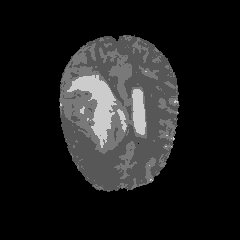

In [24]:
# @title Interactive FCM Segmentation { display-mode: "form" }
import os
from IPython.display import Image, display

# --- UI Controls ---
image_path = "images/Sample_6_Slice_97.png" # @param {type:"string"}
clusters = 4 # @param {type:"slider", min:2, max:12, step:1}
clustering_type = "Hard" # @param ["Hard", "Soft"]

# Convert string to integer flag for our C++ arguments
is_hard = 1 if clustering_type == "Hard" else 0

# Check if image exists
if not os.path.exists(image_path):
    print(f"❌ Error: Image not found at {image_path}. Please upload it.")
else:
    # Run the CUDA executable with our dynamic arguments!
    print(f"Executing: ./fcm_segmentation {image_path} {clusters} {is_hard}\n")
    !./fcm_segmentation_rgb {image_path} {clusters} {is_hard}

    # Display the result directly inside the Colab notebook
    output_img = "output_segmented_hard.png" if is_hard == 1 else "output_segmented_soft.png"
    if os.path.exists(output_img):
        print("\n--- Resulting Image ---")
        display(Image(filename=output_img))

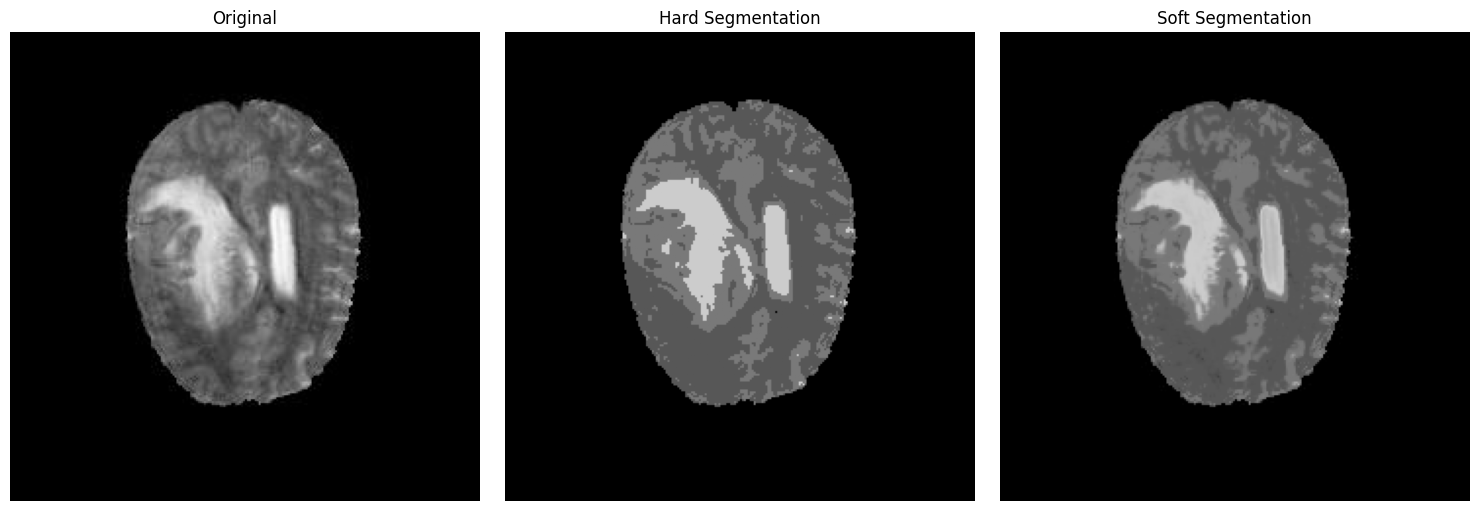

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Paths to the images
img_paths = [
    ("Original", "images/Sample_6_Slice_97.png"),
    ("Hard Segmentation", "output_segmented_hard.png"),
    ("Soft Segmentation", "output_segmented_soft.png")
]

# Create a figure to plot them side-by-side
plt.figure(figsize=(15, 5))

for i, (title, path) in enumerate(img_paths):
    plt.subplot(1, 3, i + 1)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.imshow(img, cmap='gray' if 'png' in path else None)
        plt.title(title)
    else:
        plt.text(0.5, 0.5, f"File not found:\n{path}", ha='center')
        plt.title(f"{title} (Missing)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
%%writefile FCM_Segmentation.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>
#include <cuda_runtime.h>
#include <device_launch_parameters.h>

#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

// --- Configuration ---
int C = 4;               // Number of clusters
#define M 2.0f           // Fuzziness parameter (m > 1)
#define EPSILON 0.0001f  // Convergence threshold
#define MAX_ITER 100     // Maximum iterations

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error in %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

// --- CPU Implementation ---
float calculate_distance(float p1, float p2) {
    return fabsf(p1 - p2) + 1e-6f;
}

void fcm_cpu(float* pts, float* u, float* centers, int N) {
    float* u_new = (float*)malloc(N * C * sizeof(float));
    int iter = 0;
    float max_diff;

    do {
        max_diff = 0.0f;
        for (int j = 0; j < C; j++) {
            float num = 0.0f, den = 0.0f;
            for (int i = 0; i < N; i++) {
                float u_ij_m = powf(u[i * C + j], M);
                num += u_ij_m * pts[i];
                den += u_ij_m;
            }
            centers[j] = num / den;
        }

        float exp =  2.0f / (M - 1.0f);
        for (int i = 0; i < N; i++) {
            for (int j = 0; j < C; j++) {
                float dist_ij = calculate_distance(pts[i], centers[j]);
                float sum = 0.0f;
                for (int k = 0; k < C; k++) {
                    float dist_ik = calculate_distance(pts[i], centers[k]);
                    sum += powf(dist_ij / dist_ik, exp );
                }
                u_new[i * C + j] = 1.0f / sum;

                float diff = fabsf(u_new[i * C + j] - u[i * C + j]);
                if (diff > max_diff) max_diff = diff;
            }
        }

        for (int i = 0; i < N * C; i++) u[i] = u_new[i];
        iter++;
    } while (max_diff > EPSILON && iter < MAX_ITER);

    printf("CPU finished in %d iterations.\n", iter);
    free(u_new);
}

// --- GPU Implementation ---
__global__ void calc_centers_accumulate_kernel(float* pts, float* u, float* num, float* den, int n, int c, float m) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        for (int j = 0; j < c; j++) {
            float u_ij_m = powf(u[i * c + j], m);
            atomicAdd(&num[j], u_ij_m * pts[i]);
            atomicAdd(&den[j], u_ij_m);
        }
    }
}

__global__ void calc_centers_divide_kernel(float* centers, float* num, float* den, int c) {
    int j = blockIdx.x * blockDim.x + threadIdx.x;
    if (j < c) {
        centers[j] = num[j] / den[j];
    }
}

__global__ void update_membership_kernel(float* pts, float* centers, float* u_new, int n, int c, float m) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    float exp =  2.0f / (m - 1.0f);
    if (i < n) {
        for (int j = 0; j < c; j++) {
            float dist_ij = fabsf(pts[i] - centers[j]) + 1e-6f;
            float sum = 0.0f;
            for (int k = 0; k < c; k++) {
                float dist_ik = fabsf(pts[i] - centers[k]) + 1e-6f;
                sum += powf(dist_ij / dist_ik, exp);
            }
            u_new[i * c + j] = 1.0f / sum;
        }
    }
}

void fcm_gpu(float* h_pts, float* h_u, float* h_centers, int N) {
    float *d_pts, *d_u, *d_u_new, *d_centers, *d_num, *d_den;

    size_t pts_size = N * sizeof(float);
    size_t u_size = N * C * sizeof(float);
    size_t c_size = C * sizeof(float);

    CUDA_CHECK(cudaMalloc(&d_pts, pts_size));
    CUDA_CHECK(cudaMalloc(&d_u, u_size));
    CUDA_CHECK(cudaMalloc(&d_u_new, u_size));
    CUDA_CHECK(cudaMalloc(&d_centers, c_size));
    CUDA_CHECK(cudaMalloc(&d_num, c_size));
    CUDA_CHECK(cudaMalloc(&d_den, c_size));

    CUDA_CHECK(cudaMemcpy(d_pts, h_pts, pts_size, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_u, h_u, u_size, cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks_N = (N + threads - 1) / threads;
    int blocks_C = (C + threads - 1) / threads;

    int iter = 0;
    float max_diff;
    float* h_u_new = (float*)malloc(u_size);

    do {
        CUDA_CHECK(cudaMemset(d_num, 0, c_size));
        CUDA_CHECK(cudaMemset(d_den, 0, c_size));

        calc_centers_accumulate_kernel<<<blocks_N, threads>>>(d_pts, d_u, d_num, d_den, N, C, M);
        cudaDeviceSynchronize();

        calc_centers_divide_kernel<<<blocks_C, threads>>>(d_centers, d_num, d_den, C);
        cudaDeviceSynchronize();

        update_membership_kernel<<<blocks_N, threads>>>(d_pts, d_centers, d_u_new, N, C, M);
        cudaDeviceSynchronize();

        CUDA_CHECK(cudaMemcpy(h_u_new, d_u_new, u_size, cudaMemcpyDeviceToHost));
        max_diff = 0.0f;
        for (int i = 0; i < N * C; i++) {
            float diff = fabsf(h_u_new[i] - h_u[i]);
            if (diff > max_diff) max_diff = diff;
            h_u[i] = h_u_new[i];
        }

        float* temp = d_u;
        d_u = d_u_new;
        d_u_new = temp;
        iter++;
    } while (max_diff > EPSILON && iter < MAX_ITER);

    CUDA_CHECK(cudaMemcpy(h_centers, d_centers, c_size, cudaMemcpyDeviceToHost));
    printf("GPU finished in %d iterations.\n", iter);

    free(h_u_new);
    cudaFree(d_pts); cudaFree(d_u); cudaFree(d_u_new);
    cudaFree(d_centers); cudaFree(d_num); cudaFree(d_den);
}

// --- Main Program ---
int main(int argc, char** argv) {
    const char* img_path = "images/Sample_6_Slice_97.png";
    bool hard_clustering = true;

    if (argc > 1) img_path = argv[1];
    if (argc > 2) C = atoi(argv[2]);
    if (argc > 3) hard_clustering = (atoi(argv[3]) != 0);

    int width, height, channels;
    // Force 1 channel (Grayscale)
    unsigned char* img_data = stbi_load(img_path, &width, &height, &channels, 1);
    if (!img_data) {
        fprintf(stderr, "Failed to load image: %s\n", img_path);
        return 1;
    }

    printf("Loaded image: %s (%dx%d, forced 1 channel)\n", img_path, width, height);
    printf("Settings: Clusters=%d, Mode=%s\n", C, hard_clustering ? "Hard" : "Soft");

    int N = width * height;
    srand(42);

    size_t pts_size = N * sizeof(float);
    size_t u_size = N * C * sizeof(float);
    size_t c_size = C * sizeof(float);

    float* h_pts = (float*)malloc(pts_size);
    float* h_u_initial = (float*)malloc(u_size);
    float* h_u_cpu = (float*)malloc(u_size);
    float* h_centers_cpu = (float*)malloc(c_size);
    float* h_u_gpu = (float*)malloc(u_size);
    float* h_centers_gpu = (float*)malloc(c_size);

    for (int i = 0; i < N; i++) {
        h_pts[i] = (float)img_data[i];

        float sum = 0.0f;
        for (int j = 0; j < C; j++) {
            float val = (float)rand() / RAND_MAX;
            h_u_initial[i * C + j] = val;
            sum += val;
        }
        for (int j = 0; j < C; j++) {
            h_u_initial[i * C + j] /= sum;
            h_u_cpu[i * C + j] = h_u_initial[i * C + j];
            h_u_gpu[i * C + j] = h_u_initial[i * C + j];
        }
    }

    printf("\nStarting CPU Fuzzy C-Means (1-Channel)...\n");
    clock_t start_cpu = clock();
    fcm_cpu(h_pts, h_u_cpu, h_centers_cpu, N);
    clock_t end_cpu = clock();
    printf("CPU Time: %f seconds\n", ((double)(end_cpu - start_cpu)) / CLOCKS_PER_SEC);

    printf("\nStarting GPU Fuzzy C-Means (1-Channel)...\n");
    clock_t start_gpu = clock();
    fcm_gpu(h_pts, h_u_gpu, h_centers_gpu, N);
    clock_t end_gpu = clock();
    printf("GPU Time: %f seconds\n", ((double)(end_gpu - start_gpu)) / CLOCKS_PER_SEC);

    unsigned char* out_img_data = (unsigned char*)malloc(N * 1);

    if(hard_clustering){
        for (int i = 0; i < N; i++) {
            int best_cluster = 0;
            float max_u = -1.0f;
            for (int j = 0; j < C; j++) {
                if (h_u_gpu[i * C + j] > max_u) {
                    max_u = h_u_gpu[i * C + j];
                    best_cluster = j;
                }
            }
            out_img_data[i] = (unsigned char)fminf(fmaxf(h_centers_gpu[best_cluster], 0.0f), 255.0f);
        }
    } else {
        for (int i = 0; i < N; i++) {
            float intensity = 0.0f;
            for (int j = 0; j < C; j++) {
                intensity += h_u_gpu[i * C + j] * h_centers_gpu[j];
            }
            out_img_data[i] = (unsigned char)fminf(fmaxf(intensity, 0.0f), 255.0f);
        }
    }

    const char* out_path = hard_clustering ? "output_segmented_hard.png" : "output_segmented_soft.png";
    // Write 1 channel output
    stbi_write_png(out_path, width, height, 1, out_img_data, width * 1);
    printf("\nSaved segmented image to %s\n", out_path);

    free(h_pts); free(h_u_initial);
    free(h_u_cpu); free(h_centers_cpu);
    free(h_u_gpu); free(h_centers_gpu);
    stbi_image_free(img_data);
    free(out_img_data);

    return 0;
}

Overwriting FCM_Segmentation.cu


In [17]:
!nvcc FCM_Segmentation.cu -o fcm_segmentation -O3 -w

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
# @title Interactive 1-Channel FCM Segmentation { display-mode: "form" }
import os
from IPython.display import Image, display

# --- UI Controls ---
image_path = "images/Sample_3.jpg" # @param {type:"string"}
clusters = 4 # @param {type:"slider", min:2, max:12, step:1}
clustering_type = "Soft" # @param ["Hard", "Soft"]

is_hard = 1 if clustering_type == "Hard" else 0

if not os.path.exists(image_path):
    print(f"❌ Error: Image not found at {image_path}. Please upload it.")
else:
    print(f"Executing: ./fcm_segmentation {image_path} {clusters} {is_hard}\n")
    !./fcm_segmentation {image_path} {clusters} {is_hard}

    output_img = "output_segmented_hard.png" if is_hard == 1 else "output_segmented_soft.png"
    if os.path.exists(output_img):
        print("\n--- Resulting Image ---")
        display(Image(filename=output_img))